In [18]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import pandas as pd
from keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout, GRU, Bidirectional, Input
from keras.optimizers import SGD, Adam
import math
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from keras.losses import Huber

In [20]:
def plot_predictions(test,predicted):
  plt.plot(test, color='red',label='Real IBM Stock Price')
  plt.plot(predicted, color='blue',label='Predicted IBM Stock Price')
  plt.title('IBM Stock Price Prediction')
  plt.xlabel('Time')
  plt.ylabel('IBM Stock Price')
  plt.legend()
  plt.show()

def return_rmse(test, predicted):
  rmse = math.sqrt(mean_squared_error(test, predicted))
  print("-" * 30)
  print("Błąd redniokwadratowy modelu {:.2f}.".format(rmse))
  print("-" * 30)

def return_mae(test, predicted):
  mae = mean_absolute_error(test, predicted)
  mape = mean_absolute_percentage_error(test, predicted) * 100
  print("Średni błąd bezwzględny: {:.2f}.".format(mae))
  print("Średni błąd bezwzględny procentowy: {:.2f}%".format(mape))
  print("-" * 30)

In [21]:
dataset = pd.read_csv('IBM_2006-01-01_to_2018-01-01.csv', index_col='Date', parse_dates=['Date'])
dataset.head()

,Open,High,Low,Close,Volume,Name
Date,,,,,,
2006-01-03,82.45,82.55,80.81,82.06,11715200,IBM
2006-01-04,82.20,82.50,81.33,81.95,9840600,IBM
2006-01-05,81.40,82.90,81.00,82.50,7213500,IBM
2006-01-06,83.95,85.03,83.41,84.95,8197400,IBM
2006-01-09,84.10,84.25,83.38,83.73,6858200,IBM


In [22]:
trainig_set = dataset[:'2016'].iloc[:,1:2].values
test_set = dataset['2017':].iloc[:,1:2].values

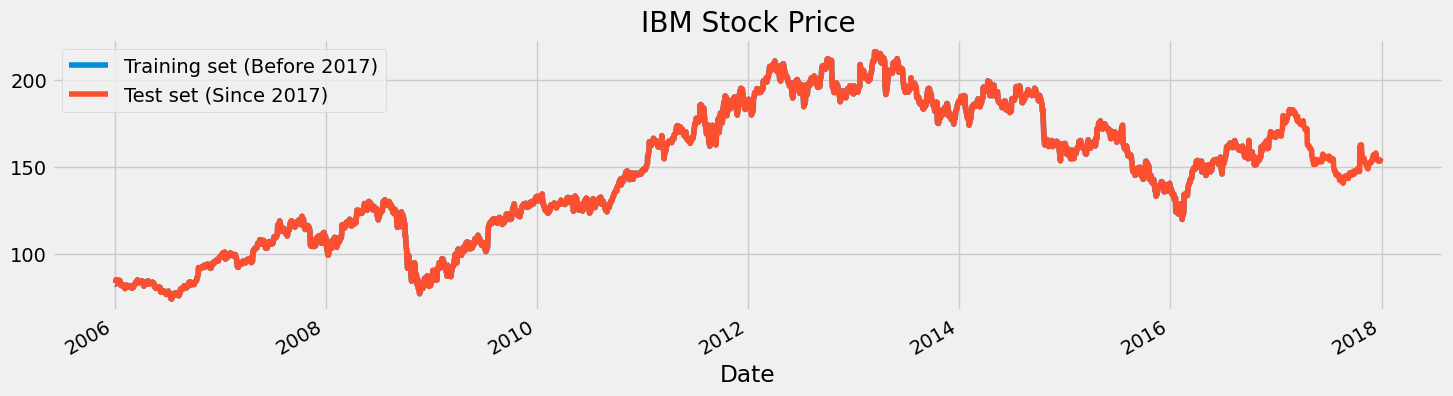

In [23]:
dataset["High"][:'2016'].plot(figsize=(16,4),legend=True)
dataset["High"][:'2017'].plot(figsize=(16,4),legend=True)
plt.legend(['Training set (Before 2017)','Test set (Since 2017)'])
plt.title('IBM Stock Price')
plt.show()

In [24]:
sc = MinMaxScaler(feature_range=(0,1))
training_set_scaled = sc.fit_transform(trainig_set)

In [28]:
X_train = []
y_train = []
for i in range(60,2769):
  X_train.append(training_set_scaled[i-60:i,0])
  y_train.append(training_set_scaled[i,0])
X_train,y_train = np.array(X_train),np.array(y_train)

In [29]:
X_train = np.reshape(X_train, (X_train.shape[0],X_train.shape[1],1))

In [31]:
regressor = Sequential()
regressor.add(Input(shape=(X_train.shape[1],1)))
regressor.add(LSTM(units=50,return_sequences=True))
regressor.add(Dropout(0.2))
regressor.add(LSTM(units=50,return_sequences=True))
regressor.add(Dropout(0.2))
regressor.add(LSTM(units=50,return_sequences=True))
regressor.add(Dropout(0.2))
regressor.add(LSTM(units=50))
regressor.add(Dropout(0.2))
regressor.add(Dense(units=1))
regressor.compile(optimizer='rmsprop',loss='mean_squared_error')
regressor.fit(X_train,y_train,epochs=100,batch_size=32)

Epoch 1/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 14s 94ms/step - loss: 0.0224
Epoch 2/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 11s 104ms/step - loss: 0.0100
Epoch 3/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 115ms/step - loss: 0.0081
Epoch 4/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 12s 142ms/step - loss: 0.0074
Epoch 5/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 8s 94ms/step - loss: 0.0062
Epoch 6/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 12s 145ms/step - loss: 0.0058
Epoch 7/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 121ms/step - loss: 0.0055
Epoch 8/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 9s 107ms/step - loss: 0.0048
Epoch 9/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 8s 97ms/step - loss: 0.0045
Epoch 10/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 93ms/step - loss: 0.0040
Epoch 11/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 9s 107ms/step - loss: 0.0038
Epoch 12/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 107ms/step - loss: 0.0038
Epoch 13/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 8s 95ms/step - loss: 0.0036
Epoch 14/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 93ms/step - loss: 0.0034
Epoch 15/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 

In [34]:
dataset_total = pd.concat((dataset["High"][:"2016"],dataset["High"]['2017':]),axis=0)
inputs = dataset_total[len(dataset_total)-len(test_set)-60:].values
inputs = inputs.reshape(-1,1)
inputs = sc.transform(inputs)

In [35]:
X_test = []
for i in range(60,311):
  X_test.append(inputs[i-60:i,0])
X_test = np.array(X_test)
X_test = np.reshape(X_test,(X_test.shape[0],X_test.shape[1],1))
predicted_stock_price = regressor.predict(X_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 127ms/step


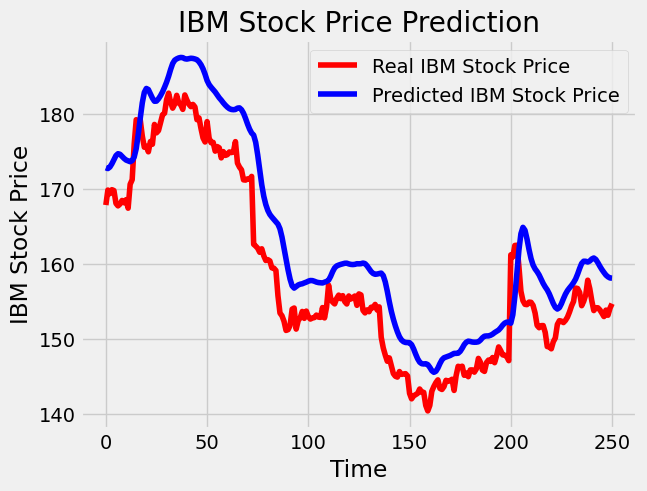

In [36]:
plot_predictions(test_set,predicted_stock_price)

In [37]:
return_rmse(test_set,predicted_stock_price)
return_mae(test_set,predicted_stock_price)

------------------------------
Błąd redniokwadratowy modelu 5.77.
------------------------------
Średni błąd bezwzględny: 5.32.
Średni błąd bezwzględny procentowy: 3.35%
------------------------------


In [ ]:
regressorGRU = Sequential()
regressorGRU.add(Input(shape=(X_train.shape[1],1)))
regressorGRU.add(GRU(units=50,return_sequences=True,activation='tanh'))
regressorGRU.add(Dropout(0.2))
regressorGRU.add(GRU(units=50,return_sequences=True,activation='tanh'))
regressorGRU.add(Dropout(0.2))
regressorGRU.add(GRU(units=50,return_sequences=True,activation='tanh'))
regressorGRU.add(Dropout(0.2))
regressorGRU.add(GRU(units=50,activation='tanh'))
regressorGRU.add(Dropout(0.2))
regressorGRU.add(Dense(units=1))
regressorGRU.compile(optimizer='rmsprop',loss='mean_squared_error')
early_stop = EarlyStopping(monitor='loss',patience=5,restore_best_weights=True)
regressorGRU.fit(X_train,y_train,epochs=100,batch_size=32,callbacks=[early_stop])

Epoch 1/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 19s 138ms/step - loss: 0.0164
Epoch 2/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 12s 144ms/step - loss: 0.0090
Epoch 3/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 13s 154ms/step - loss: 0.0073
Epoch 4/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 11s 134ms/step - loss: 0.0057
Epoch 5/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 11s 126ms/step - loss: 0.0056
Epoch 6/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 11s 133ms/step - loss: 0.0051
Epoch 7/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 21s 136ms/step - loss: 0.0046
Epoch 8/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 20s 135ms/step - loss: 0.0041
Epoch 9/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 11s 134ms/step - loss: 0.0040
Epoch 10/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 21s 136ms/step - loss: 0.0039
Epoch 11/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 11s 135ms/step - loss: 0.0036
Epoch 12/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 12s 136ms/step - loss: 0.0035
Epoch 13/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 11s 135ms/step - loss: 0.0033
Epoch 14/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 11s 134ms/step - loss: 0.0030
Epoch 15/100
85/85 ━━━━━━━━━━

In [ ]:
X_test = []
for i in range(60,311):
  X_test.append(inputs[i-60:i,0])
X_test = np.array(X_test)
X_test = np.reshape(X_test,(X_test.shape[0],X_test.shape[1],1))
GRU_predicted_stock_price = regressorGRU.predict(X_test)
GRU_predicted_stock_price = sc.inverse_transform(GRU_predicted_stock_price)

In [ ]:
plot_predictions(test_set,GRU_predicted_stock_price)

In [ ]:
return_rmse(test_set,GRU_predicted_stock_price)
return_mae(test_set,GRU_predicted_stock_price)